# Comparación: Baseline - RAG + NLI base (3 clases, SIN fine-tuning) — CPU

Código Civil Peruano — clases `contradiction` / `entailment` / `neutral`.

**Notas para correr en CPU (Docker Jupyter, sin GPU):**
- No usa ningún checkpoint fine-tuneado, solo el modelo NLI base.
- `bge-m3` y `nli-deberta-v3-large` son modelos grandes; en CPU son lentos pero
  perfectamente ejecutables para este tamaño de corpus/gold set (2135 artículos,
  146 pares de evaluación). Calcula ~15-30 min en total dependiendo de tu CPU
  (el paso más lento es indexar el corpus la primera vez; luego queda cacheado
  en disco con Qdrant).
- Si tu máquina es muy limitada, hay una celda opcional al final de la sección 4
  para usar un modelo NLI base más liviano (`cross-encoder/nli-deberta-v3-base`,
  ~184M parámetros en vez de ~400M) sin perder las 3 clases nativas.


In [ ]:
# 0. Instalación
# !pip install sentence-transformers qdrant-client transformers torch scikit-learn pandas matplotlib seaborn tqdm rank_bm25 -q


In [ ]:
import json
import os
import time
import numpy as np
import pandas as pd
from collections import Counter
from pathlib import Path

import torch
from sentence_transformers import SentenceTransformer, CrossEncoder
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from rank_bm25 import BM25Okapi
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score,
    classification_report, confusion_matrix, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


DEVICE = "cpu"
torch.set_num_threads(os.cpu_count())
print(f"Dispositivo: {DEVICE} | Núcleos usados: {os.cpu_count()}")


/usr/local/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Dispositivo: cpu | Núcleos usados: 12


## 1. Configuración

In [ ]:
CORPUS_PATH = "corpus_cc_peru.json"
GOLD_PATH   = "gold_dataset_3clases.json"     
QDRANT_DIR  = "./qdrant_storage_3clases"
COLLECTION  = "cc_peru_3clases"

EMBEDDING_MODEL = "BAAI/bge-m3"
NLI_BASE_MODEL  = "cross-encoder/nli-deberta-v3-large"   # modelo BASE, sin fine-tuning

TOP_K   = 10
BATCH   = 32          
CLASES_3 = ["contradiction", "entailment", "neutral"]

RESULTS_DIR = Path("results_3clases")
RESULTS_DIR.mkdir(exist_ok=True)


## 2. Cargar corpus y gold set

In [4]:
with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus = json.load(f)
print(f"Corpus: {len(corpus)} articulos")

for tema, n in Counter(a.get("tema_legal", "otros") for a in corpus).most_common(8):
    print(f"  {n:>4} -- {tema}")

art_por_num = {str(a["articulo"]): a for a in corpus}
art_por_idx = {i: corpus[i] for i in range(len(corpus))}


Corpus: 2135 articulos
   596 -- otros
   371 -- personas
   238 -- obligaciones
   196 -- sucesiones
   170 -- familia
   140 -- procesal
   139 -- derechos_reales
   135 -- contratos


In [5]:
with open(GOLD_PATH, "r", encoding="utf-8") as f:
    gold_dataset = json.load(f)
print(f"Gold dataset (3 clases): {len(gold_dataset)} pares")

dist3 = Counter(p["etiqueta_3clases"] for p in gold_dataset)
for c, n in dist3.items():
    print(f"  {c:>14}: {n:>3} ({n/len(gold_dataset)*100:.1f}%)")

y_3clases = [p["etiqueta_3clases"] for p in gold_dataset]


Gold dataset (3 clases): 146 pares
         neutral:  77 (52.7%)
   contradiction:  34 (23.3%)
      entailment:  35 (24.0%)


## 3. Índices de recuperación (denso + BM25)

`bge-m3` en CPU tarda más al indexar los 2135 artículos la primera vez
(esperá varios minutos). Qdrant guarda el índice en disco (`QDRANT_DIR`), así
que si volvés a correr el notebook con los mismos datos, este paso se salta.


In [6]:
print("Cargando bge-m3 (CPU)...")
t0 = time.time()
embedding_model = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
print(f"bge-m3 cargado en {time.time()-t0:.1f}s")


Cargando bge-m3 (CPU)...
bge-m3 cargado en 6.6s


In [7]:
qdrant = QdrantClient(path=QDRANT_DIR)

if not qdrant.collection_exists(COLLECTION):
    qdrant.create_collection(
        collection_name=COLLECTION,
        vectors_config=VectorParams(size=embedding_model.get_sentence_embedding_dimension(),
                                     distance=Distance.COSINE),
    )
    print(f"Indexando {len(corpus)} articulos (puede tardar varios minutos en CPU)...")
    t0 = time.time()
    for i in range(0, len(corpus), BATCH):
        lote = corpus[i:i+BATCH]
        vecs = embedding_model.encode([a["texto"] for a in lote],
                                       normalize_embeddings=True, show_progress_bar=False).tolist()
        qdrant.upsert(collection_name=COLLECTION, points=[
            PointStruct(id=i+j, vector=v, payload={"articulo": lote[j]["articulo"], "texto": lote[j]["texto"]})
            for j, v in enumerate(vecs)
        ])
        if (i // BATCH) % 5 == 0:
            print(f"  {min(i+BATCH, len(corpus))}/{len(corpus)}  ({time.time()-t0:.0f}s transcurridos)")
    print(f"Indexado completo en {time.time()-t0:.1f}s")
else:
    print(f"Qdrant: {qdrant.get_collection(COLLECTION).points_count} vectores ya indexados (reutilizando cache en disco)")


Qdrant: 2135 vectores ya indexados (reutilizando cache en disco)


In [8]:
def tokenize_fn(t):
    return t.lower().split()

print("Construyendo BM25...")
corpus_tokens = [tokenize_fn(a["texto"]) for a in corpus]
bm25_index = BM25Okapi(corpus_tokens)
print(f"BM25 listo ({len(corpus)} docs)")


Construyendo BM25...
BM25 listo (2135 docs)


## 4. Modelo NLI base (3 clases nativas, SIN fine-tuning)

Carga `cross-encoder/nli-deberta-v3-large` tal cual viene de Hugging Face — no
se carga ningún checkpoint LoRA ni fine-tuneado.


In [9]:
print("Cargando NLI base (sin fine-tuning)...")
t0 = time.time()
nli_base = CrossEncoder(NLI_BASE_MODEL, max_length=512, device=DEVICE)
print(f"Cargado en {time.time()-t0:.1f}s")
print(f"id2label base: {nli_base.config.id2label}")


Cargando NLI base (sin fine-tuning)...
Cargado en 2.9s
id2label base: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}


## 5. Funciones de recuperación

In [11]:
def recuperar_denso(texto, top_k=TOP_K, excluir_art=None):
    vector = embedding_model.encode(texto, normalize_embeddings=True).tolist()
    res = qdrant.query_points(collection_name=COLLECTION, query=vector,
                               limit=top_k+2, with_payload=True).points
    return [{"articulo": r.payload["articulo"], "texto": r.payload["texto"], "score": round(r.score, 4)}
            for r in res if not excluir_art or r.payload["articulo"] != excluir_art][:top_k]

def recuperar_bm25(texto, top_k=TOP_K, excluir_art=None):
    tokens = tokenize_fn(texto)
    scores = bm25_index.get_scores(tokens)
    resultado = []
    for idx in np.argsort(scores)[::-1]:
        art = art_por_idx[idx]
        if excluir_art and str(art["articulo"]) == excluir_art:
            continue
        resultado.append({"articulo": str(art["articulo"]), "texto": art["texto"],
                           "score": round(float(scores[idx]), 4)})
        if len(resultado) == top_k:
            break
    return resultado

def recuperar_hibrido(texto, top_k=TOP_K, excluir_art=None, alpha=0.6):
    densos = recuperar_denso(texto, top_k=top_k*2, excluir_art=excluir_art)
    bm25s  = recuperar_bm25(texto, top_k=top_k*2, excluir_art=excluir_art)
    sd = {r["articulo"]: r["score"] for r in densos}
    mb = max((r["score"] for r in bm25s), default=1.0) + 1e-10
    sb = {r["articulo"]: r["score"]/mb for r in bm25s}
    arts = set(sd) | set(sb)
    return sorted(
        [{"articulo": a, "texto": art_por_num.get(a, {}).get("texto", ""),
          "score": round(alpha*sd.get(a, 0)+(1-alpha)*sb.get(a, 0), 4)}
         for a in arts if art_por_num.get(a)],
        key=lambda x: -x["score"]
    )[:top_k]

print("Funciones de recuperación definidas")


Funciones de recuperación definidas


## 6. Clasificador NLI base - 3 clases (sin fine-tuning)

In [12]:
def clasificar_base(ta, tb):
    scores = nli_base.predict([[ta[:512], tb[:512]]], apply_softmax=True)[0]
    labels = {i: l.lower() for i, l in nli_base.config.id2label.items()}
    sd = {labels[i]: float(scores[i]) for i in range(len(scores))}
    return {"etiqueta": max(sd, key=sd.get), "scores": sd}

print("Clasificador definido")


Clasificador definido


## 7. Métricas de recuperación (Recall@k, Precision@k, MRR)

Solo tiene sentido para pares que sí tienen relación (se excluyen los
`NO_RELACION` del gold original de 5 clases, que no tienen un `articulo_b`
significativo que recuperar).


In [13]:
print("=== METRICAS DEL RECUPERADOR ===")
pares_eval = [p for p in gold_dataset if p["etiqueta_final"] != "NO_RELACION" and str(p["articulo_b"]) in art_por_num]
print(f"Pares evaluables: {len(pares_eval)}")

def eval_retriever(fn_rec, pares, k_vals=[5, 10, 15]):
    filas = []
    for k in k_vals:
        hits, rr_list, prec_list = 0, [], []
        for p in tqdm(pares, desc=f"k={k}", leave=False):
            cands = fn_rec(p["texto_a"], top_k=k, excluir_art=str(p["articulo_a"]))
            arts_rec = [c["articulo"] for c in cands]
            art_b = str(p["articulo_b"])
            if art_b in arts_rec:
                hits += 1
                rank = arts_rec.index(art_b) + 1
                rr_list.append(1.0/rank)
                prec_list.append(1.0/k)
            else:
                rr_list.append(0.0)
                prec_list.append(0.0)
        n = len(pares)
        filas.append({"k": k, f"Recall@{k}": round(hits/n, 4),
                       f"Precision@{k}": round(np.mean(prec_list), 4),
                       f"MRR@{k}": round(np.mean(rr_list), 4)})
    return filas

rows_all = []
for nombre, fn in [("BM25 lexico", recuperar_bm25), ("Denso bge-m3", recuperar_denso),
                   ("Hibrido a=0.6", recuperar_hibrido)]:
    print(f"\n{nombre}")
    filas = eval_retriever(fn, pares_eval)
    for f in filas:
        k = f["k"]
        print(f"  k={k}: Recall={f[f'Recall@{k}']:.4f} Precision={f[f'Precision@{k}']:.4f} MRR={f[f'MRR@{k}']:.4f}")
        rows_all.append({"Recuperador": nombre, **f})

df_ret = pd.DataFrame(rows_all)
df_ret.to_csv(RESULTS_DIR/"metricas_retriever_3clases.csv", index=False)
print(f"\nGuardado en {RESULTS_DIR}/metricas_retriever_3clases.csv")


=== METRICAS DEL RECUPERADOR ===
Pares evaluables: 101

BM25 lexico


k=5:   0%|          | 0/101 [00:00<?, ?it/s]

k=10:   0%|          | 0/101 [00:00<?, ?it/s]

k=15:   0%|          | 0/101 [00:00<?, ?it/s]

  k=5: Recall=0.2772 Precision=0.0554 MRR=0.1941
  k=10: Recall=0.3465 Precision=0.0347 MRR=0.2026
  k=15: Recall=0.3960 Precision=0.0264 MRR=0.2070

Denso bge-m3


...

  k=5: Recall=0.3564 Precision=0.0713 MRR=0.2457
  k=10: Recall=0.5050 Precision=0.0505 MRR=0.2655
  k=15: Recall=0.5842 Precision=0.0389 MRR=0.2717

Hibrido a=0.6


k=5:   0%|          | 0/101 [00:00<?, ?it/s]

k=10:   0%|          | 0/101 [00:00<?, ?it/s]

k=15:   0%|          | 0/101 [00:00<?, ?it/s]

  k=5: Recall=0.3762 Precision=0.0752 MRR=0.2503
  k=10: Recall=0.4851 Precision=0.0485 MRR=0.2699
  k=15: Recall=0.5545 Precision=0.0370 MRR=0.2693

Guardado en results_3clases/metricas_retriever_3clases.csv


## 8. Ablation: Baseline - BM25+NLI - Denso+NLI - Híbrido+NLI

Todo con el modelo NLI **base** (sin fine-tuning). Métrica objetivo: F1 de la
clase `contradiction` (equivalente a tu `f1_contradiccion` original).


In [14]:
UMBRAL_COSENO = 0.55   # ajusta segun lo que ya calibraste en tu notebook original

def config1_baseline_coseno(par):
    """Similitud coseno pura entre texto_a y texto_b (sin NLI)."""
    t0 = time.time()
    va = embedding_model.encode(par["texto_a"], normalize_embeddings=True)
    vb = embedding_model.encode(par["texto_b"], normalize_embeddings=True)
    sim = float(np.dot(va, vb))
    pred = "contradiction" if sim < (1 - UMBRAL_COSENO) else "neutral"
    return pred, round((time.time()-t0)*1000, 1)

def config2_nli_base_par_real(par):
    """Clasificador NLI puro contra el par verdadero del gold (sin retriever)."""
    t0 = time.time()
    out = clasificar_base(par["texto_a"], par["texto_b"])
    return out["etiqueta"], round((time.time()-t0)*1000, 1)

def config3_denso_nli_pipeline(par):
    """Pipeline end-to-end: retriever denso recupera top-1, NLI clasifica contra lo RECUPERADO."""
    t0 = time.time()
    cands = recuperar_denso(par["texto_a"], top_k=TOP_K, excluir_art=str(par["articulo_a"]))
    tb = cands[0]["texto"] if cands else par["texto_b"]
    out = clasificar_base(par["texto_a"], tb)
    return out["etiqueta"], round((time.time()-t0)*1000, 1)

def config4_hibrido_nli_pipeline(par):
    """Pipeline end-to-end: retriever hibrido recupera top-1, NLI clasifica contra lo RECUPERADO."""
    t0 = time.time()
    cands = recuperar_hibrido(par["texto_a"], top_k=TOP_K, excluir_art=str(par["articulo_a"]))
    tb = cands[0]["texto"] if cands else par["texto_b"]
    out = clasificar_base(par["texto_a"], tb)
    return out["etiqueta"], round((time.time()-t0)*1000, 1)

CONFIGS = [
    ("1_baseline_coseno",      config1_baseline_coseno),
    ("2_nli_base_par_real",    config2_nli_base_par_real),   # techo del clasificador puro
    ("3_denso_nli_pipeline",   config3_denso_nli_pipeline),  # RAG end-to-end (denso)
    ("4_hibrido_nli_pipeline", config4_hibrido_nli_pipeline),# RAG end-to-end (hibrido)
]
print(f"{len(CONFIGS)} configuraciones definidas")


4 configuraciones definidas


In [15]:
print("=== ABLATION 3 CLASES (SIN FINE-TUNING) — puede tardar varios minutos en CPU ===")

resultados = {}
for nombre, fn in CONFIGS:
    y_true, y_pred, lats = [], [], []
    for par in tqdm(gold_dataset, desc=nombre):
        pred, lat = fn(par)
        y_true.append(par["etiqueta_3clases"])
        y_pred.append(pred)
        lats.append(lat)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=["contradiction"], average="macro", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    resultados[nombre] = {"y_true": y_true, "y_pred": y_pred,
                          "precision": p, "recall": r, "f1": f1,
                          "accuracy": acc, "latencia_ms": np.mean(lats)}
    print(f"  {nombre:<28} P={p:.3f} R={r:.3f} F1(contradiction)={f1:.3f} Acc(3clases)={acc:.3f} [{np.mean(lats):.0f}ms]")

df_ablation = pd.DataFrame([
    {"Configuracion": n, "Precision": v["precision"], "Recall": v["recall"],
     "F1_contradiction": v["f1"], "Accuracy_3clases": v["accuracy"], "Latencia_ms": v["latencia_ms"]}
    for n, v in resultados.items()
])
df_ablation.to_csv(RESULTS_DIR/"tabla_ablation_3clases.csv", index=False)
print(f"\nGuardado en {RESULTS_DIR}/tabla_ablation_3clases.csv")
df_ablation


=== ABLATION 3 CLASES (SIN FINE-TUNING) — puede tardar varios minutos en CPU ===


1_baseline_coseno:   0%|          | 0/146 [00:00<?, ?it/s]

  1_baseline_coseno            P=0.000 R=0.000 F1(contradiction)=0.000 Acc(3clases)=0.459 [4712ms]


2_nli_base_par_real:   0%|          | 0/146 [00:00<?, ?it/s]

  2_nli_base_par_real          P=0.206 R=0.206 F1(contradiction)=0.206 Acc(3clases)=0.411 [2852ms]


3_denso_nli_pipeline:   0%|          | 0/146 [00:00<?, ?it/s]

  3_denso_nli_pipeline         P=0.231 R=0.176 F1(contradiction)=0.200 Acc(3clases)=0.404 [5058ms]


4_hibrido_nli_pipeline:   0%|          | 0/146 [00:00<?, ?it/s]

  4_hibrido_nli_pipeline       P=0.206 R=0.206 F1(contradiction)=0.206 Acc(3clases)=0.384 [10350ms]

Guardado en results_3clases/tabla_ablation_3clases.csv


,Configuracion,Precision,Recall,F1_contradiction,Accuracy_3clases,Latencia_ms
0,1_baseline_coseno,0.000000,0.000000,0.000000,0.458904,4711.976027
1,2_nli_base_par_real,0.205882,0.205882,0.205882,0.410959,2852.242466
2,3_denso_nli_pipeline,0.230769,0.176471,0.200000,0.404110,5058.478767
3,4_hibrido_nli_pipeline,0.205882,0.205882,0.205882,0.383562,10349.798630


## 9. Reporte detallado (3 clases) de la mejor configuración

In [16]:
mejor_cfg = max(resultados, key=lambda k: resultados[k]["f1"])
print(f"=== REPORTE DETALLADO — {mejor_cfg} ===")
y_true_best = resultados[mejor_cfg]["y_true"]
y_pred_best = resultados[mejor_cfg]["y_pred"]

print(classification_report(y_true_best, y_pred_best, labels=CLASES_3, zero_division=0))


=== REPORTE DETALLADO — 2_nli_base_par_real ===
               precision    recall  f1-score   support

contradiction       0.21      0.21      0.21        34
   entailment       0.16      0.09      0.11        35
      neutral       0.54      0.65      0.59        77

     accuracy                           0.41       146
    macro avg       0.30      0.31      0.30       146
 weighted avg       0.37      0.41      0.38       146



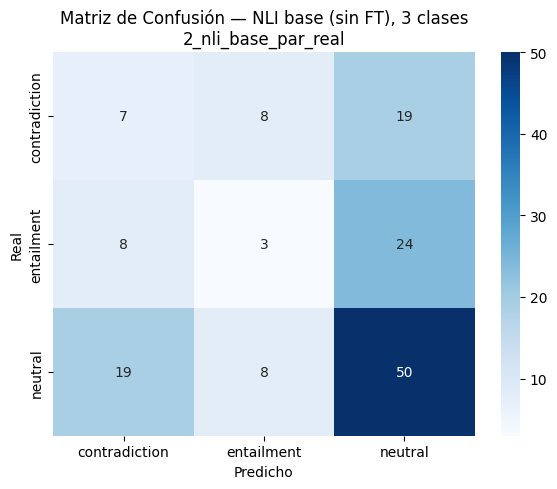

In [17]:
cm = confusion_matrix(y_true_best, y_pred_best, labels=CLASES_3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASES_3, yticklabels=CLASES_3)
plt.title(f"Matriz de Confusión — NLI base (sin FT), 3 clases\n{mejor_cfg}")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig(RESULTS_DIR/"matriz_confusion_3clases.png", dpi=150)
plt.show()


## 10. Resumen final para el capítulo de resultados de la tesis

In [ ]:
print("="*70)
print("RESUMEN — Comparación baseline a RAG+NLI base (3 clases, sin fine-tuning)")
print("="*70)
print(f"Corpus:      {len(corpus)} articulos CC Peru")
print(f"Gold dataset: {len(gold_dataset)} pares (3 clases: contradiction/entailment/neutral)")
print(f"Distribucion: {dist3}")
print(f"\nMejor config: {mejor_cfg}")
print(f"  F1 (contradiction): {resultados[mejor_cfg]['f1']:.4f}")
print(f"  Precision:          {resultados[mejor_cfg]['precision']:.4f}")
print(f"  Recall:             {resultados[mejor_cfg]['recall']:.4f}")
print(f"  Accuracy (3 clases): {resultados[mejor_cfg]['accuracy']:.4f}")
print("\nNotas:")
print("  1. Este pipeline NO usa ningun checkpoint fine-tuneado.")
print("  2. 'config2_nli_base_par_real' mide el techo del clasificador puro (par verdadero).")
print("  3. 'config3' y 'config4' son pipeline end-to-end (RAG real): usan lo que el retriever")
print("     encuentra, no el par verdadero. Compara su F1 contra config2 para medir cuanto")
print("     degrada el resultado un retriever imperfecto.")

reporte = {
    "corpus": {"n": len(corpus)},
    "gold": {"total": len(gold_dataset), "dist": dict(dist3)},
    "ablation": {n: {"f1": round(v["f1"], 4), "precision": round(v["precision"], 4),
                      "recall": round(v["recall"], 4), "accuracy": round(v["accuracy"], 4),
                      "latencia_ms": round(v["latencia_ms"], 1)} for n, v in resultados.items()},
    "mejor_config": mejor_cfg,
}
with open(RESULTS_DIR/"reporte_3clases.json", "w", encoding="utf-8") as f:
    json.dump(reporte, f, ensure_ascii=False, indent=2)
print(f"\nReporte completo guardado en {RESULTS_DIR}/reporte_3clases.json")


---
## 11. Recalcular métricas sobre el gold set LIMPIO

Se excluyen 3 casos diacrónicos (Art. 3, 44, 95 — comparan texto derogado vs.
vigente del mismo artículo, fuera del alcance de un clasificador NLI sincrónico)
y se deduplica el par 1681/1683 (estaba contado dos veces, en ambas direcciones).
Gold set: 146 - 142 pares.


In [ ]:
with open("gold_dataset_5clases_evaluacion.json", "r", encoding="utf-8") as f:
    _limpio = json.load(f)

gold_dataset_limpio = _limpio["gold"]
print(f"Gold set limpio: {len(gold_dataset_limpio)} pares")
print(f"Excluidos: {_limpio['meta']['excluidos']} ({_limpio['meta']['criterio_exclusion']})")

dist3_limpio = Counter(p["etiqueta_3clases"] for p in gold_dataset_limpio)
print("Distribucion 3 clases:", dist3_limpio)


In [ ]:
# Re-correr el ablation (seccion 8) sobre el gold set limpio
resultados_limpio = {}
for nombre, fn in CONFIGS:
    y_true, y_pred, lats = [], [], []
    for par in tqdm(gold_dataset_limpio, desc=nombre):
        pred, lat = fn(par)
        y_true.append(par["etiqueta_3clases"])
        y_pred.append(pred)
        lats.append(lat)

    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=["contradiction"], average="macro", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    resultados_limpio[nombre] = {"y_true": y_true, "y_pred": y_pred,
                          "precision": p, "recall": r, "f1": f1,
                          "accuracy": acc, "latencia_ms": np.mean(lats)}
    print(f"  {nombre:<28} P={p:.3f} R={r:.3f} F1(contradiction)={f1:.3f} Acc(3clases)={acc:.3f}")

df_ablation_limpio = pd.DataFrame([
    {"Configuracion": n, "Precision": v["precision"], "Recall": v["recall"],
     "F1_contradiction": v["f1"], "Accuracy_3clases": v["accuracy"]}
    for n, v in resultados_limpio.items()
])
df_ablation_limpio.to_csv(RESULTS_DIR/"tabla_ablation_3clases_LIMPIO.csv", index=False)
print(f"\nGuardado en {RESULTS_DIR}/tabla_ablation_3clases_LIMPIO.csv")
df_ablation_limpio


### Intervalo de confianza (bootstrap) sobre F1(contradiction)

Con un n chico (142 pares, ~30 de contradicción), un solo caso mal clasificado
mueve el F1 varios puntos. Un intervalo de confianza por bootstrap es lo mínimo
para poder defender el número en la sustentación.


In [ ]:
def bootstrap_f1_contradiction(y_true, y_pred, n_iter=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    n = len(y_true)
    f1s = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        f1 = f1_score(y_true[idx], y_pred[idx], labels=["contradiction"],
                       average="macro", zero_division=0)
        f1s.append(f1)
    f1s = np.array(f1s)
    return np.percentile(f1s, 2.5), np.percentile(f1s, 50), np.percentile(f1s, 97.5)

print("Intervalo de confianza 95% (bootstrap, 2000 iteraciones) para F1(contradiction):\n")
for nombre, v in resultados_limpio.items():
    lo, mid, hi = bootstrap_f1_contradiction(v["y_true"], v["y_pred"])
    print(f"  {nombre:<28} F1={v['f1']:.3f}  IC95%=[{lo:.3f}, {hi:.3f}]  (mediana bootstrap={mid:.3f})")


### Métricas de recuperación sobre el gold set limpio (Recall@k, % cita correcta)

In [ ]:
pares_eval_limpio = [p for p in gold_dataset_limpio if p["etiqueta_final"] != "NO_RELACION" and str(p["articulo_b"]) in art_por_num]
print(f"Pares evaluables (limpio): {len(pares_eval_limpio)}")

rows_limpio = []
for nombre, fn in [("BM25 lexico", recuperar_bm25), ("Denso bge-m3", recuperar_denso),
                   ("Hibrido a=0.6", recuperar_hibrido)]:
    filas = eval_retriever(fn, pares_eval_limpio, k_vals=[5, 10, 15])
    for f in filas:
        k = f["k"]
        print(f"  {nombre} k={k}: Recall={f[f'Recall@{k}']:.4f} Precision={f[f'Precision@{k}']:.4f}")
        rows_limpio.append({"Recuperador": nombre, **f})

print("\n% de citas correctas (top-1 exacto), gold limpio:")
for nombre, fn in [("BM25", recuperar_bm25), ("Denso bge-m3", recuperar_denso),
                   ("Hibrido a=0.6", recuperar_hibrido)]:
    c, t, pct = pct_citas_correctas(fn, gold_dataset_limpio)
    print(f"  {nombre:<15}: {c}/{t} = {pct*100:.1f}%")

pd.DataFrame(rows_limpio).to_csv(RESULTS_DIR/"metricas_retriever_3clases_LIMPIO.csv", index=False)
